# ML и DL

ML (mlforecast): Ridge, Lasso, RandomForest, XGBoost, LightGBM. DL (neuralforecast): LSTM, NHITS, DLinear.

In [1]:
# !pip install -q mlforecast neuralforecast lightgbm xgboost


In [2]:
import sys, os, json
from pathlib import Path
ROOT = Path('.').resolve()
if not (ROOT / 'src').exists() and (ROOT.parent / 'src').exists():
    ROOT = ROOT.parent
    os.chdir(ROOT)
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (12, 4)

from src.data import load_panel, DAILY_SEASON, WEEKLY_SEASON, FREQ
from src.eval import make_metrics, evaluate_panel
from src.features import DEFAULT_DATE_FEATURES

panel = load_panel()
H = DAILY_SEASON   # горизонт = 1 сутки
_test_raw = panel.groupby('unique_id').tail(H)
train_fold = panel.drop(_test_raw.index).reset_index(drop=True)
test_fold = _test_raw.reset_index(drop=True)
metrics, metric_names = make_metrics(seasonality=DAILY_SEASON)
print(f'Train: {len(train_fold)}; Test: {len(test_fold)}; H={H}')


Train: 11229; Test: 864; H=288


## ML: mlforecast

Признаки: сезонное дифференцирование `Differences([288])`, лаги `[1,2,3,6,12,288]` + скользящие средние, календарные sin/cos часа и дня недели, `is_weekend`.

In [3]:
from mlforecast import MLForecast
from mlforecast.target_transforms import Differences
from mlforecast.lag_transforms import RollingMean

from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor

models_ml = {
    'Ridge': Ridge(alpha=1.0),
    'Lasso': Lasso(alpha=0.01, max_iter=5000),
    'RF': RandomForestRegressor(n_estimators=100, max_depth=10, n_jobs=-1, random_state=42),
    'XGB': XGBRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                       n_jobs=-1, random_state=42, verbosity=0),
    'LGBM': LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                         n_jobs=-1, random_state=42, verbosity=-1),
}

fcst_ml = MLForecast(
    models=models_ml,
    freq=FREQ,
    lags=[1, 2, 3, 6, 12, DAILY_SEASON],
    lag_transforms={
        1: [RollingMean(window_size=12)],
        DAILY_SEASON: [RollingMean(window_size=DAILY_SEASON)],
    },
    target_transforms=[Differences([DAILY_SEASON])],
    date_features=DEFAULT_DATE_FEATURES,
)
fcst_ml.fit(train_fold)
preds_ml = fcst_ml.predict(h=H)
preds_ml.head(2)


,unique_id,ds,Ridge,Lasso,RF,XGB,LGBM
0,ec2_cpu_utilization_24ae8d,2014-02-27 14:25:00,0.145080,0.121065,0.199959,0.193497,0.203802
1,ec2_cpu_utilization_24ae8d,2014-02-27 14:30:00,0.118305,0.103952,0.131959,0.137424,0.135802


In [4]:
eval_ml = test_fold.merge(preds_ml, on=['unique_id', 'ds'])
m_ml = evaluate_panel(
    eval_df=eval_ml, train_df=train_fold,
    model_names=list(models_ml.keys()), metrics=metrics,
)
print('ML hold-out:')
m_ml


ML hold-out:


,unique_id,Ridge,Lasso,RF,XGB,LGBM
metric,,,,,,
mae,ec2_cpu_utilization_24ae8d,0.210923,0.307394,0.045549,0.046935,0.045877
mae,ec2_cpu_utilization_53ea38,0.194998,0.291018,0.056464,0.055870,0.056971
mae,ec2_cpu_utilization_5f5533,0.858360,0.887781,0.719821,0.688895,0.705150
rmse,ec2_cpu_utilization_24ae8d,0.270775,0.351397,0.164407,0.156572,0.163659
rmse,ec2_cpu_utilization_53ea38,0.230892,0.319964,0.087355,0.086592,0.087857
rmse,ec2_cpu_utilization_5f5533,1.063764,1.099118,0.914585,0.873631,0.901796
smape,ec2_cpu_utilization_24ae8d,0.665298,0.976333,0.138166,0.139996,0.136864
smape,ec2_cpu_utilization_53ea38,0.055862,0.087706,0.015262,0.015097,0.015387
smape,ec2_cpu_utilization_5f5533,0.011291,0.011694,0.009420,0.009007,0.009224


Лучшая ML-модель по MAE: XGB (MAE=0.2639)

Все ML модели (mean MAE по рядам):
XGB      0.263900
LGBM     0.269333
RF       0.273945
Ridge    0.421427
Lasso    0.495398
dtype: float64


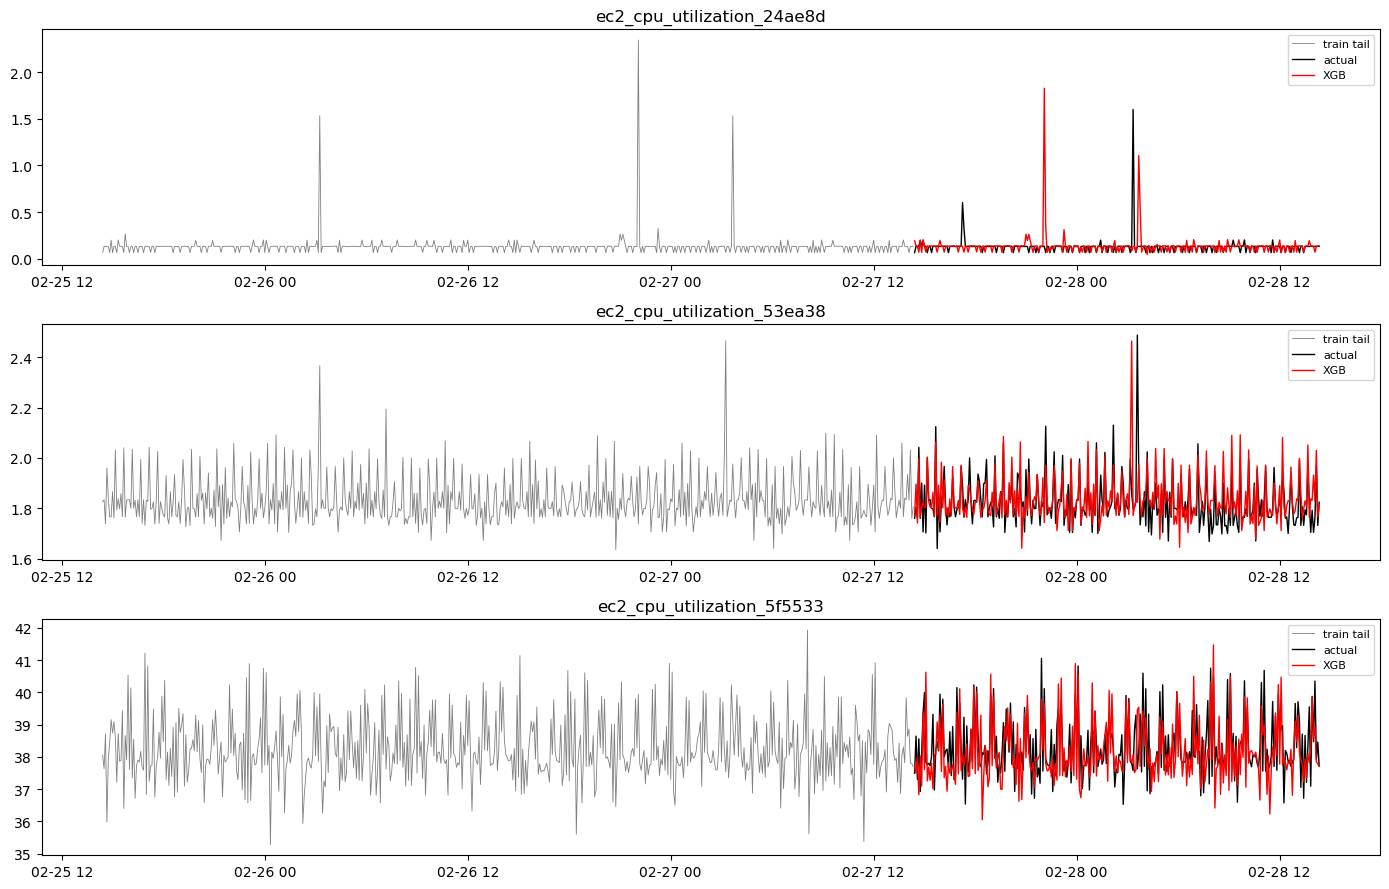

In [5]:
# Лучшая ML-модель по MAE
mae_means = m_ml.loc['mae'].select_dtypes('number').mean()
ml_winner = mae_means.idxmin()
print(f'Лучшая ML-модель по MAE: {ml_winner} (MAE={mae_means.min():.4f})')
print()
print('Все ML модели (mean MAE по рядам):')
print(mae_means.sort_values())

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=False)
for ax, uid in zip(axes, panel['unique_id'].unique()):
    sub_train = train_fold[train_fold['unique_id']==uid].tail(2*DAILY_SEASON)
    sub_eval = eval_ml[eval_ml['unique_id']==uid]
    ax.plot(sub_train['ds'], sub_train['y'], color='gray', linewidth=0.6, label='train tail')
    ax.plot(sub_eval['ds'], sub_eval['y'], color='black', linewidth=1, label='actual')
    ax.plot(sub_eval['ds'], sub_eval[ml_winner], color='red', linewidth=1, label=ml_winner)
    ax.set_title(uid); ax.legend(fontsize=8)
plt.tight_layout()
plt.savefig('report/figures/04_ml_winner.png', dpi=120, bbox_inches='tight')
plt.show()


### Direct vs Recursive стратегии

In [6]:
fcst_direct = MLForecast(
    models={'LGBM_direct': LGBMRegressor(n_estimators=200, max_depth=6, learning_rate=0.05,
                                         n_jobs=-1, random_state=42, verbosity=-1)},
    freq=FREQ,
    lags=[1, 2, 3, 6, 12, DAILY_SEASON],
    target_transforms=[Differences([DAILY_SEASON])],
    date_features=DEFAULT_DATE_FEATURES,
)
fcst_direct.fit(train_fold, max_horizon=H)
preds_direct = fcst_direct.predict(h=H)
eval_direct = test_fold.merge(preds_direct, on=['unique_id', 'ds'])
m_direct = evaluate_panel(
    eval_df=eval_direct, train_df=train_fold,
    model_names=['LGBM_direct'], metrics=metrics,
)
print('Direct strategy (LGBM):')
m_direct


Direct strategy (LGBM):


,unique_id,LGBM_direct
metric,,
mae,ec2_cpu_utilization_24ae8d,0.052904
mae,ec2_cpu_utilization_53ea38,0.060799
mae,ec2_cpu_utilization_5f5533,0.775654
rmse,ec2_cpu_utilization_24ae8d,0.186625
rmse,ec2_cpu_utilization_53ea38,0.091387
rmse,ec2_cpu_utilization_5f5533,0.981008
smape,ec2_cpu_utilization_24ae8d,0.151275
smape,ec2_cpu_utilization_53ea38,0.016381
smape,ec2_cpu_utilization_5f5533,0.010149


### Permutation feature importance (LGBM)

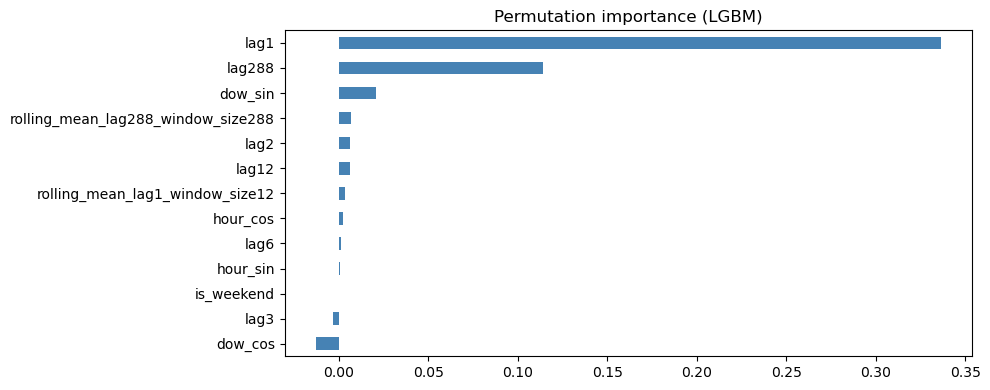

Топ-5 признаков: ['lag1', 'lag288', 'dow_sin', 'rolling_mean_lag288_window_size288', 'lag2']


In [7]:
from sklearn.inspection import permutation_importance

prep = fcst_ml.preprocess(train_fold)
feature_cols = [c for c in prep.columns if c not in ['unique_id','ds','y']]
X = prep[feature_cols]; y = prep['y']
model = fcst_ml.models_['LGBM']
X_val, y_val = X.iloc[-H:], y.iloc[-H:]
result = permutation_importance(model, X_val, y_val, n_repeats=5, random_state=42, n_jobs=-1)

imp = pd.Series(result.importances_mean, index=feature_cols).sort_values(ascending=True)
plt.figure(figsize=(10, max(4, 0.3*len(imp))))
imp.plot.barh(color='steelblue')
plt.title('Permutation importance (LGBM)')
plt.tight_layout()
plt.savefig('report/figures/04_feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print(f'Топ-5 признаков: {list(imp.sort_values(ascending=False).head(5).index)}')


## DL: neuralforecast

DL на коротких рядах (~4000 точек) может проигрывать stats. Для сравнения использую 3 архитектуры.

In [8]:
import torch
print(f'CUDA: {torch.cuda.is_available()}, MPS: {torch.backends.mps.is_available()}')

from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NHITS, DLinear
from neuralforecast.losses.pytorch import MAE

# 50 шагов для скорости локально, в Colab можно 500-1000
MAX_STEPS = 50

models_dl = [
    LSTM(
        h=H, input_size=3*H, max_steps=MAX_STEPS,
        encoder_hidden_size=64, decoder_hidden_size=64,
        scaler_type='standard', loss=MAE(),
    ),
    NHITS(
        h=H, input_size=H, max_steps=MAX_STEPS,
        n_freq_downsample=[24, 12, 1],
        scaler_type='standard', loss=MAE(),
    ),
    DLinear(
        h=H, input_size=2*H, max_steps=MAX_STEPS,
        moving_avg_window=25,
        scaler_type='standard', loss=MAE(),
    ),
]
nf = NeuralForecast(models=models_dl, freq=FREQ)


CUDA: False, MPS: True


Seed set to 1


Seed set to 1


Seed set to 1


In [9]:
VAL = H  # 1 сутки на val
nf.fit(df=train_fold, val_size=VAL)
preds_dl = nf.predict(df=train_fold)
preds_dl.head(2)


GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores



  | Name         | Type          | Params | Mode 
-------------------------------------------------------
0 | loss         | MAE           | 0      | train
1 | padder_train | ConstantPad1d | 0      | train
2 | scaler       | TemporalNorm  | 0      | train
3 | hist_encoder | LSTM          | 50.4 K | train
4 | mlp_decoder  | MLP           | 4.2 K  | train
-------------------------------------------------------
54.7 K    Trainable params
0         Non-trainable params
54.7 K    Total params
0.219     Total estimated model params size (MB)
10        Modules in train mode
0         Modules in eval mode


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

Training: |          | 0/? [00:00<?, ?it/s]

...

Predicting: |          | 0/? [00:00<?, ?it/s]

GPU available: True (mps), used: True


TPU available: False, using: 0 TPU cores


Predicting: |          | 0/? [00:00<?, ?it/s]

,unique_id,ds,LSTM,NHITS,DLinear
0,ec2_cpu_utilization_24ae8d,2014-02-27 14:25:00,0.134050,0.139943,0.259030
1,ec2_cpu_utilization_24ae8d,2014-02-27 14:30:00,0.134356,0.142030,0.104701


In [10]:
eval_dl = test_fold.merge(preds_dl, on=['unique_id', 'ds'])
dl_aliases = ['LSTM', 'NHITS', 'DLinear']
# в neuralforecast 3.x колонки именуются по архитектуре
present_aliases = [a for a in dl_aliases if a in preds_dl.columns]
print(f'Колонки прогнозов: {present_aliases}')

m_dl = evaluate_panel(
    eval_df=eval_dl, train_df=train_fold,
    model_names=present_aliases, metrics=metrics,
)
m_dl


Колонки прогнозов: ['LSTM', 'NHITS', 'DLinear']


,unique_id,LSTM,NHITS,DLinear
metric,,,,
mae,ec2_cpu_utilization_24ae8d,0.022768,0.031691,0.068060
mae,ec2_cpu_utilization_53ea38,0.072722,0.043519,0.058106
mae,ec2_cpu_utilization_5f5533,0.774523,0.672721,0.748493
rmse,ec2_cpu_utilization_24ae8d,0.096489,0.097923,0.122227
rmse,ec2_cpu_utilization_53ea38,0.098205,0.067446,0.081955
rmse,ec2_cpu_utilization_5f5533,0.953788,0.857756,0.956020
smape,ec2_cpu_utilization_24ae8d,0.079006,0.109507,0.271424
smape,ec2_cpu_utilization_53ea38,0.019691,0.011844,0.015802
smape,ec2_cpu_utilization_5f5533,0.010074,0.008746,0.009740


## Сравнение Stats vs ML vs DL

In [11]:
# победитель stats из nb02
with open('data/processed/winner_stat.json') as f:
    winner_stat_name = json.load(f).get('winner_stat', 'MSTL_d')

# Сводная таблица: MAE для всех
all_mae = {}
for src_df, label in [
    (m_ml, 'ML'),
    (m_dl, 'DL'),
]:
    means = src_df.loc['mae'].select_dtypes('number').mean()
    for k, v in means.items():
        all_mae[f'{label}_{k}'] = v

# Добавим stats-победителя
stats_metrics = pd.read_csv('data/processed/stats_metrics.csv')
sm = stats_metrics[stats_metrics['metric']=='mae']
for col in [c for c in sm.columns if c not in ('metric','unique_id')]:
    all_mae[f'Stat_{col}'] = sm[col].mean()

mae_summary = pd.Series(all_mae).sort_values()
print('Сравнение Stat vs ML vs DL (mean MAE):')
print(mae_summary)


Сравнение Stat vs ML vs DL (mean MAE):
DL_NHITS        0.249310
ML_XGB          0.263900
ML_LGBM         0.269333
ML_RF           0.273945
Stat_SNaive     0.281294
Stat_HW         0.287704
DL_LSTM         0.290004
DL_DLinear      0.291553
Stat_Naive      0.295683
Stat_Theta      0.326642
Stat_MSTL_d     0.340458
Stat_RWD        0.356794
ML_Ridge        0.421427
ML_Lasso        0.495398
Stat_MSTL_dw    0.857654
Stat_ETS        2.069852
dtype: float64


In [12]:
# Сохраним победителей и forecasts
ml_winner = m_ml.loc['mae'].select_dtypes('number').mean().idxmin()
dl_winner = m_dl.loc['mae'].select_dtypes('number').mean().idxmin() if len(present_aliases) else None

with open('data/processed/winners.json', 'w') as f:
    json.dump({
        'stat': str(winner_stat_name),
        'ml': str(ml_winner),
        'dl': str(dl_winner) if dl_winner else None,
        'h': H,
    }, f, indent=2)

eval_ml.to_parquet('data/processed/ml_forecasts.parquet', index=False)
eval_dl.to_parquet('data/processed/dl_forecasts.parquet', index=False)

print(f'stat={winner_stat_name}, ml={ml_winner}, dl={dl_winner}')


stat=SNaive, ml=XGB, dl=NHITS
